In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [4]:
# Load the dataset
df = pd.read_csv(r"C:\Users\user\OneDrive\Pictures\Documents\Desktop\Multiple_Regression_HousePrice_Dataset.csv")

# Preview first 10 rows
print(df.head(10))

# Check shape and types
print(df.shape)   # (160, 6)
df.info()


   Property_ID  Area_sqft  Bedrooms  Age_years  Distance_City_km  \
0            1       1959         1          0              15.1   
1            2        859         5          2              12.2   
2            3        715         1          2               5.2   
3            4       1057         5         13               5.2   
4            5       1856         3         25              17.5   
5            6       1515         3          8               4.0   
6            7       2213         3          3               2.8   
7            8       1886         3         25               1.8   
8            9       1590         5          3              19.5   
9           10       2348         5         28              17.4   

   House_Price_Lakhs  
0              87.38  
1              76.56  
2              40.24  
3              83.60  
4              80.81  
5              88.93  
6             135.88  
7             105.59  
8              93.10  
9             122.33 

In [5]:
# Independent variables (features)
X = df[["Area_sqft", "Bedrooms", "Age_years", "Distance_City_km"]]

# Dependent variable (target)
y = df["House_Price_Lakhs"]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


In [7]:
# Independent variables (features)
X = df[["Area_sqft", "Bedrooms", "Age_years", "Distance_City_km"]]

# Dependent variable (target)
y = df["House_Price_Lakhs"]


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


In [9]:
# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0.05, 8.64,-0.62,-1.1 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Area_sqft','Bedrooms','Age_years','Distance_City_km']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.624
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [10]:
print("Intercept:", model.intercept_)
# Intercept: 4.6241

coefficient_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coefficient_table)

Intercept: 4.624056765573059
            Feature  Coefficient
0         Area_sqft     0.046232
1          Bedrooms     8.638083
2         Age_years    -0.622968
3  Distance_City_km    -1.100034


In [11]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})
print(results.head(10))

   Actual Price  Predicted Price
0         37.07        37.820099
1         82.68        80.571659
2         76.48        69.983643
3        126.91       127.922228
4         94.51        99.540731
5         66.18        69.240490
6        104.86        98.986666
7        127.65       115.728515
8        104.35       102.345829
9         53.45        52.845262


In [12]:
mse = mean_squared_error(y_test, y_pred)


In [13]:
rmse = np.sqrt(mse)


In [14]:
r2 = r2_score(y_test, y_pred)
# R² ≈ 0.9742


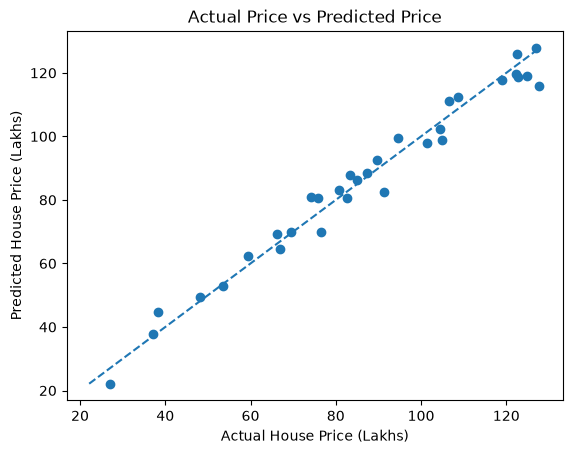

In [15]:
plt.scatter(y_test, y_pred)
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.xlabel("Actual House Price (Lakhs)")
plt.ylabel("Predicted House Price (Lakhs)")
plt.title("Actual Price vs Predicted Price")
plt.show()


In [16]:
new_house = pd.DataFrame({
    "Area_sqft": [1800],
    "Bedrooms": [3],
    "Age_years": [5],
    "Distance_City_km": [7]
})
predicted_price = model.predict(new_house)
print("Predicted Price:", predicted_price[0], "Lakhs")


Predicted Price: 102.94058598970516 Lakhs
